# Trader Performance vs Market Sentiment

**Primetrade.ai — Data Science Assignment**

Exploring the relationship between Hyperliquid trader performance and the Bitcoin Fear/Greed Index.

**Datasets**
1. `fear_greed_index.csv` — daily market sentiment (Extreme Fear → Extreme Greed)
2. `historical_data.csv` — ~211k Hyperliquid trade fills (account, coin, price, size, side, direction, closed PnL, fee, timestamp)

**Approach:** clean → merge trades to that day's sentiment → compare performance & behaviour across sentiment regimes → extract actionable insights.

> Note: the brief mentioned a `leverage` column. It is **not present** in this export, so leverage analysis is omitted and position *size* (Size USD) is used as the risk-appetite proxy instead.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# If running in Colab, upload the two CSVs first:
# from google.colab import files; files.upload()
FG_PATH = 'fear_greed_index.csv'
HIST_PATH = 'historical_data.csv'

In [4]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index (1).csv


## 2. Load & Inspect

In [5]:
fg = pd.read_csv(FG_PATH)
hist = pd.read_csv(HIST_PATH)

print('Fear/Greed:', fg.shape)
print('Historical:', hist.shape)
fg.head()

Fear/Greed: (2644, 4)
Historical: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,"895,000,000,000,000.00","1,730,000,000,000.00"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,"443,000,000,000,000.00","1,730,000,000,000.00"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,02-12-2024 22:50,"1,002.52",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"660,000,000,000,000.00","1,730,000,000,000.00"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,"1,142.04",BUY,02-12-2024 22:50,"1,146.56",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"1,080,000,000,000,000.00","1,730,000,000,000.00"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,"1,289.49",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,"1,050,000,000,000,000.00","1,730,000,000,000.00"


In [7]:
print('Sentiment classes:')
print(fg['classification'].value_counts())
print('\nTrade directions:')
print(hist['Direction'].value_counts())

Sentiment classes:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Trade directions:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


## 3. Clean & Prepare

In [8]:
# --- Sentiment: parse date, keep 5-class + a collapsed 2-class view ---
fg['date'] = pd.to_datetime(fg['date']).dt.date

# --- Trades: parse the IST timestamp, derive trade date ---
hist['dt'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['dt'].dt.date

# numeric safety
for c in ['Closed PnL', 'Size USD', 'Execution Price', 'Fee']:
    hist[c] = pd.to_numeric(hist[c], errors='coerce')

print('Trade date range :', hist['date'].min(), '->', hist['date'].max())
print('Sentiment range  :', fg['date'].min(), '->', fg['date'].max())
print('Null Closed PnL  :', hist['Closed PnL'].isna().sum())

Trade date range : 2023-05-01 -> 2025-05-01
Sentiment range  : 2018-02-01 -> 2025-05-02
Null Closed PnL  : 0


## 4. Merge — join each trade to that day's sentiment
This is the core step. We inner-join on calendar date.

In [9]:
df = hist.merge(fg[['date', 'classification', 'value']], on='date', how='inner')

print(f'Merged rows: {len(df):,} / {len(hist):,}  ({100*len(df)/len(hist):.1f}% matched)')

# 5-class ordering + collapsed Fear/Greed view
ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df['classification'] = pd.Categorical(df['classification'], categories=ORDER, ordered=True)
df['sentiment'] = df['classification'].astype(str).replace(
    {'Extreme Fear': 'Fear', 'Extreme Greed': 'Greed'})

# trade-level helpers
df['win'] = df['Closed PnL'] > 0
df['is_long'] = df['Direction'].str.contains('Long', na=False)
df['is_short'] = df['Direction'].str.contains('Short', na=False)
df.head()

Merged rows: 211,218 / 211,224  (100.0% matched)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Trade ID,Timestamp,dt,date,classification,value,sentiment,win,is_long,is_short
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,02-12-2024 22:50,0.00,Buy,0.00,...,"895,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02,Extreme Greed,80,Greed,False,False,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,...,"443,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02,Extreme Greed,80,Greed,False,False,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,02-12-2024 22:50,"1,002.52",Buy,0.00,...,"660,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02,Extreme Greed,80,Greed,False,False,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,"1,142.04",BUY,02-12-2024 22:50,"1,146.56",Buy,0.00,...,"1,080,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02,Extreme Greed,80,Greed,False,False,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,"1,289.49",Buy,0.00,...,"1,050,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02,Extreme Greed,80,Greed,False,False,False


## 5. Performance by Sentiment Regime

In [10]:
perf = df.groupby('classification', observed=True).agg(
    trades=('Closed PnL', 'size'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', lambda x: x.mean() * 100),
    avg_size_usd=('Size USD', 'mean'),
).reindex(ORDER)
perf

,trades,avg_pnl,median_pnl,total_pnl,win_rate,avg_size_usd
classification,,,,,,
Extreme Fear,21400,34.54,0.00,"739,110.25",37.06,"5,349.73"
Fear,61837,54.29,0.00,"3,357,155.44",42.08,"7,816.11"
Neutral,37686,34.31,0.00,"1,292,920.68",39.70,"4,782.73"
Greed,50303,42.74,0.00,"2,150,129.27",38.48,"5,736.88"
Extreme Greed,39992,67.89,0.00,"2,715,171.31",46.49,"3,112.25"


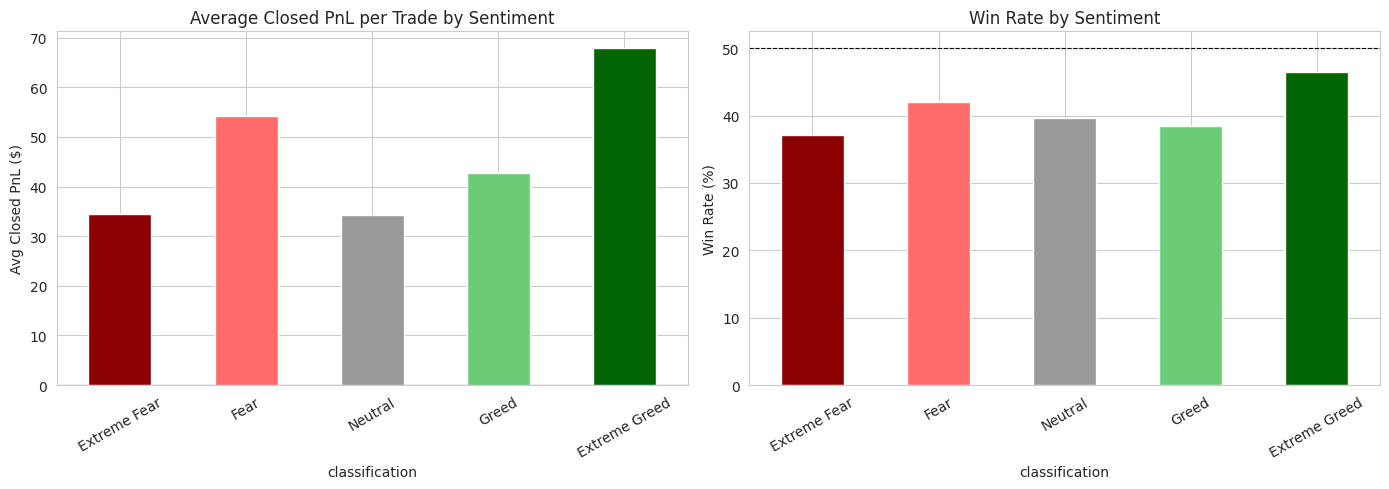

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#8B0000', '#FF6B6B', '#999999', '#6BCB77', '#006400']

perf['avg_pnl'].plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Average Closed PnL per Trade by Sentiment')
ax[0].set_ylabel('Avg Closed PnL ($)'); ax[0].axhline(0, color='k', lw=0.8)
ax[0].tick_params(axis='x', rotation=30)

perf['win_rate'].plot(kind='bar', ax=ax[1], color=colors)
ax[1].set_title('Win Rate by Sentiment'); ax[1].set_ylabel('Win Rate (%)')
ax[1].axhline(50, color='k', ls='--', lw=0.8); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Read:** Profitability is *not* monotonic with greed. **Extreme Greed** shows the highest avg PnL and win rate — but on the *smallest* average position size. **Fear** days generate the largest total PnL (driven by high volume + large size).

## 6. Risk Appetite — Position Size by Sentiment

/tmp/ipykernel_807/2475415227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Size USD'] < df['Size USD'].quantile(0.95)],


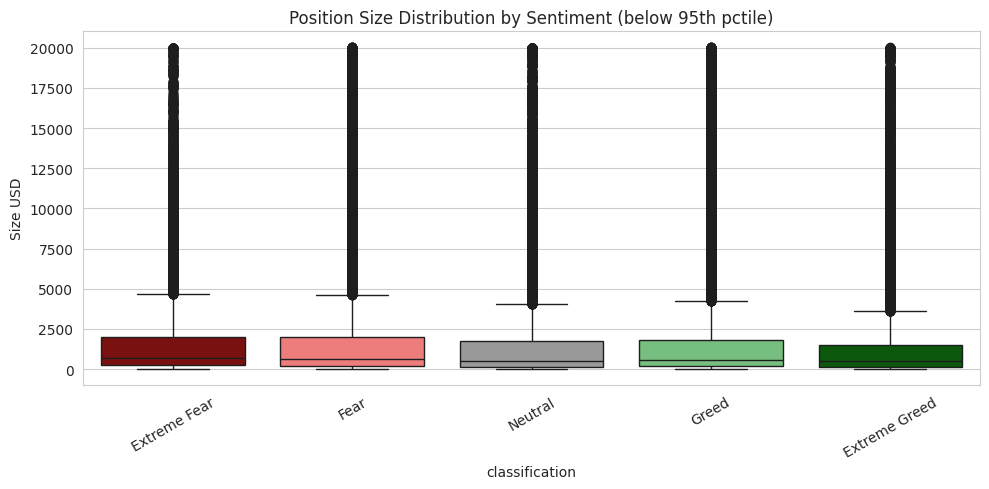

classification
Extreme Fear    766.15
Fear            735.96
Neutral         547.65
Greed           555.00
Extreme Greed   500.05
Name: Size USD, dtype: float64


In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['Size USD'] < df['Size USD'].quantile(0.95)],
            x='classification', y='Size USD', order=ORDER, palette=colors)
plt.title('Position Size Distribution by Sentiment (below 95th pctile)')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

print(df.groupby('classification', observed=True)['Size USD'].median().reindex(ORDER))

**Read:** Traders size up most aggressively during **Fear** and shrink positions during **Extreme Greed** — the opposite of a naive FOMO assumption. Bigger bets in fear, smaller bets when euphoric.

## 7. Directional Bias — Long vs Short by Sentiment

/tmp/ipykernel_807/2634266735.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bias = ds.groupby('classification', observed=True).apply(


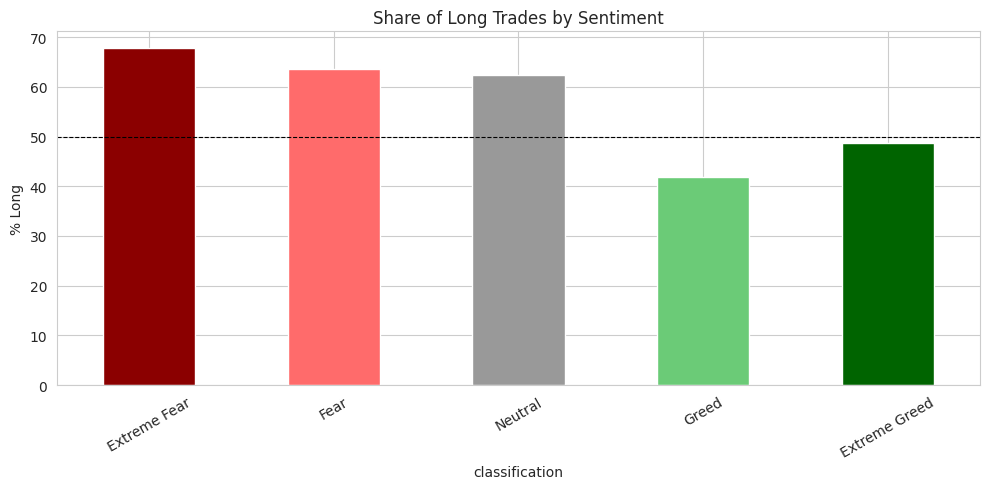

,0
classification,
Extreme Fear,67.80
Fear,63.60
Neutral,62.30
Greed,41.90
Extreme Greed,48.80


In [13]:
ds = df[df['is_long'] | df['is_short']].copy()
bias = ds.groupby('classification', observed=True).apply(
    lambda d: 100 * d['is_long'].sum() / (d['is_long'].sum() + d['is_short'].sum())
).reindex(ORDER)

bias.plot(kind='bar', color=colors, figsize=(10,5))
plt.axhline(50, color='k', ls='--', lw=0.8)
plt.title('Share of Long Trades by Sentiment'); plt.ylabel('% Long')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
bias.round(1)

**Read:** Clear contrarian skew. Traders lean **long during Fear (~64–68%)** and flip toward **short/balanced during Greed (~42–49%)**. The crowd buys dips in fear and de-risks in greed.

## 8. Same-Trader Comparison: Fear vs Greed
Controls for trader skill — does the *same* account perform differently across regimes?

In [14]:
pair = (df[df['sentiment'].isin(['Fear', 'Greed'])]
        .groupby(['Account', 'sentiment'], observed=True)['Closed PnL']
        .mean().unstack().dropna())

print(f'Accounts active in BOTH regimes: {len(pair)}')
print(f'Better in Fear : {(pair["Fear"] > pair["Greed"]).sum()}')
print(f'Better in Greed: {(pair["Greed"] >= pair["Fear"]).sum()}')
print('\nMean of per-account avg PnL:')
print(pair.mean().round(2))

Accounts active in BOTH regimes: 31
Better in Fear : 10
Better in Greed: 21

Mean of per-account avg PnL:
sentiment
Fear    70.64
Greed   98.21
dtype: float64


## 9. Sentiment vs Daily Aggregate PnL Over Time

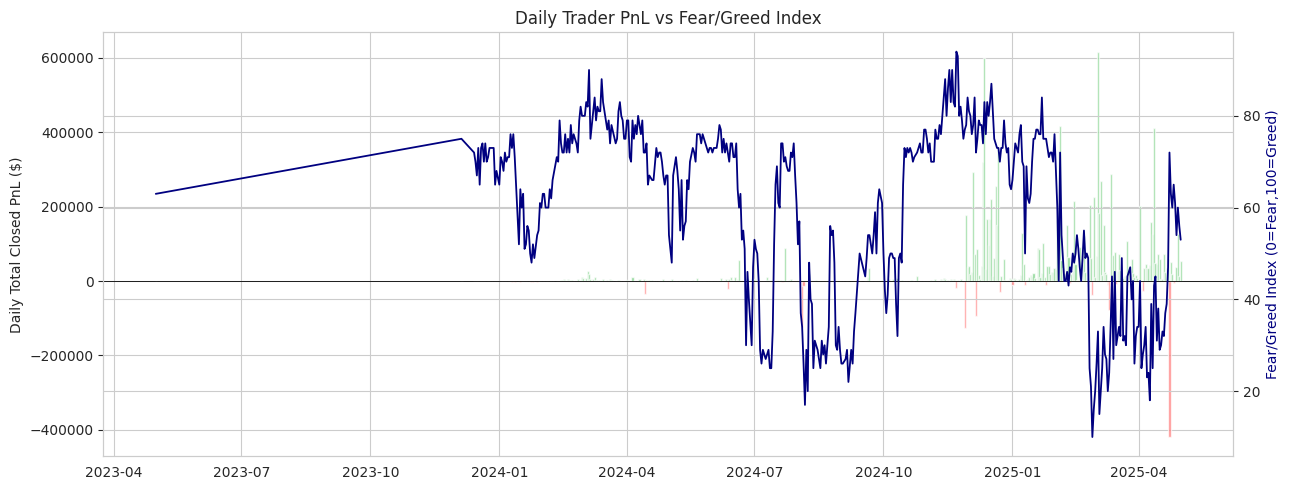

In [15]:
daily = df.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    sentiment_value=('value', 'first')).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(daily['date'], daily['total_pnl'], width=1.5,
        color=np.where(daily['total_pnl'] >= 0, '#6BCB77', '#FF6B6B'), alpha=0.7)
ax1.set_ylabel('Daily Total Closed PnL ($)'); ax1.axhline(0, color='k', lw=0.6)
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['sentiment_value'], color='navy', lw=1.3)
ax2.set_ylabel('Fear/Greed Index (0=Fear,100=Greed)', color='navy')
plt.title('Daily Trader PnL vs Fear/Greed Index'); plt.tight_layout(); plt.show()

## 10. Correlation Check

In [16]:
corr = daily[['total_pnl', 'sentiment_value']].corr().iloc[0,1]
print(f'Correlation (daily total PnL vs sentiment value): {corr:.3f}')

# does today's sentiment predict tomorrow's PnL?
daily['pnl_next'] = daily['total_pnl'].shift(-1)
lag = daily[['sentiment_value','pnl_next']].dropna().corr().iloc[0,1]
print(f'Lag correlation (today sentiment vs tomorrow PnL): {lag:.3f}')

Correlation (daily total PnL vs sentiment value): -0.083
Lag correlation (today sentiment vs tomorrow PnL): -0.108


## 11. Key Insights & Recommendations

1. **Profit peaks in Extreme Greed, not Fear — but on the smallest sizes.** Extreme Greed shows the best win rate (~46%) and highest avg PnL per trade, yet the smallest median position. Quality over size when euphoric.

2. **Traders over-size in Fear.** Largest median positions appear on Fear days. Total PnL is highest in Fear mainly because of volume + size, not edge per trade — the win rate in Fear is actually *below* Extreme Greed.

3. **Behaviour is contrarian by construction.** ~64–68% long during Fear vs ~42–49% long during Greed. The cohort buys fear and de-risks/shorts greed — a textbook mean-reversion posture.

4. **Sentiment alone is a weak direct predictor of PnL** (correlation near zero on daily aggregates). Sentiment shapes *positioning and sizing behaviour* far more than it linearly drives outcomes.

5. **Edge is in the extremes.** Neutral days are the worst regime (low avg PnL, middling win rate). The actionable zones are Extreme Fear and Extreme Greed, not the middle.

**Strategy takeaways**
- Cut position size during Fear — the data shows traders over-bet there without a matching win-rate edge.
- Lean into disciplined, smaller positions during Extreme Greed where realised win rate is highest.
- Treat Neutral as a low-edge regime; reduce activity.
- Use sentiment as a *risk/sizing governor*, not a directional signal on its own.

> Caveats: leverage data unavailable; closed-PnL = 0 rows are opening fills (no realised PnL yet); outliers winsorised only in the size boxplot. A multi-factor model (sentiment + volatility + funding) would be the next step.